In [ ]:
from google.colab import files
uploaded = files.upload()

import copy
import zipfile
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

train_raw = pd.read_csv('train.csv')
test_raw = pd.read_csv('test.csv')
print('Training shape:', train_raw.shape)
print('Kaggle test shape:', test_raw.shape)

In [ ]:
# Shared feature engineering, preprocessing, and validation split
def engineer_features(data):
    result = data[['PassengerId', 'Pclass', 'Name', 'Sex', 'Age',
                   'SibSp', 'Parch', 'Fare', 'Embarked']].copy()
    result['FamilySize'] = result['SibSp'] + result['Parch'] + 1
    result['IsAlone'] = (result['FamilySize'] == 1).astype(int)
    result['FarePerPerson'] = result['Fare'] / result['FamilySize']
    result['Title'] = result['Name'].str.extract(r',\s*([^.]*)\.', expand=False)
    common_titles = ['Mr', 'Mrs', 'Miss', 'Master']
    result['Title'] = result['Title'].where(result['Title'].isin(common_titles), 'Rare')
    return result.drop(columns=['Name']).set_index('PassengerId')

X_all = engineer_features(train_raw)
X_kaggle = engineer_features(test_raw)
y_all = train_raw.set_index('PassengerId')['Survived']

numeric_features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare',
                    'FamilySize', 'IsAlone', 'FarePerPerson']
categorical_features = ['Sex', 'Embarked', 'Title']

preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), categorical_features)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.33, random_state=10, stratify=y_all
)

assert len(X_valid) == 295
assert X_train.index.equals(y_train.index)
assert X_valid.index.equals(y_valid.index)
print('Shared features:', X_all.columns.tolist())
print('Training rows:', len(X_train), '| Validation rows:', len(X_valid))

Shared features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'FamilySize', 'IsAlone', 'FarePerPerson', 'Title']
Training rows: 596 | Validation rows: 295


In [ ]:
!pip -q install deap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 93.1/93.1 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 879.5/879.5 kB 16.6 MB/s eta 0:00:00


In [ ]:
import copy
import math
import operator
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functools import partial
from sklearn.base import clone
from sklearn.metrics import confusion_matrix

from deap import base, creator, gp, tools

warnings.filterwarnings("ignore")

RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)


# Use the same preprocessor as the five earlier ML models.
# Fit only on the training fold to prevent validation leakage.
gp_preprocessor = clone(preprocessor)

X_train_gp = gp_preprocessor.fit_transform(X_train)
X_valid_gp = gp_preprocessor.transform(X_valid)
X_kaggle_gp = gp_preprocessor.transform(X_kaggle)

X_train_gp = np.asarray(X_train_gp, dtype=float)
X_valid_gp = np.asarray(X_valid_gp, dtype=float)
X_kaggle_gp = np.asarray(X_kaggle_gp, dtype=float)

y_train_gp = np.asarray(y_train, dtype=int)
y_valid_gp = np.asarray(y_valid, dtype=int)

feature_names = gp_preprocessor.get_feature_names_out()

print("Training shape:", X_train_gp.shape)
print("Validation shape:", X_valid_gp.shape)
print("Kaggle-test shape:", X_kaggle_gp.shape)
print("Number of GP inputs:", len(feature_names))
print("\nProcessed features:")

for index, name in enumerate(feature_names):
    print(f"x{index}: {name}")

Training shape: (596, 18)
Validation shape: (295, 18)
Kaggle-test shape: (418, 18)
Number of GP inputs: 18

Processed features:
x0: numeric__Pclass
x1: numeric__Age
x2: numeric__SibSp
x3: numeric__Parch
x4: numeric__Fare
x5: numeric__FamilySize
x6: numeric__IsAlone
x7: numeric__FarePerPerson
x8: categorical__Sex_female
x9: categorical__Sex_male
x10: categorical__Embarked_C
x11: categorical__Embarked_Q
x12: categorical__Embarked_S
x13: categorical__Title_Master
x14: categorical__Title_Miss
x15: categorical__Title_Mr
x16: categorical__Title_Mrs
x17: categorical__Title_Rare


In [ ]:
# Protected operations prevent crashes caused by division by zero,
# overflow, invalid square roots, or invalid logarithms.

def protected_divide(left, right):
    if abs(right) < 1e-10:
        return left

    result = left / right

    if not math.isfinite(result):
        return 0.0

    return result


def protected_log(value):
    return math.log(abs(value) + 1e-10)


def protected_sqrt(value):
    return math.sqrt(abs(value))


def protected_exp(value):
    # Restrict the input to prevent numerical overflow.
    value = max(-20.0, min(20.0, value))
    return math.exp(value)


def safe_min(left, right):
    return min(left, right)


def safe_max(left, right):
    return max(left, right)


# One float argument for every processed feature.
pset = gp.PrimitiveSet(
    "MAIN",
    arity=X_train_gp.shape[1]
)

# Give the arguments readable names x0, x1, ...
for index in range(X_train_gp.shape[1]):
    pset.renameArguments(**{f"ARG{index}": f"x{index}"})


pset.addPrimitive(operator.add, 2)
pset.addPrimitive(operator.sub, 2)
pset.addPrimitive(operator.mul, 2)
pset.addPrimitive(protected_divide, 2)
pset.addPrimitive(safe_min, 2)
pset.addPrimitive(safe_max, 2)

pset.addPrimitive(operator.neg, 1)
pset.addPrimitive(abs, 1)
pset.addPrimitive(protected_log, 1)
pset.addPrimitive(protected_sqrt, 1)
pset.addPrimitive(protected_exp, 1)

pset.addEphemeralConstant(
    "random_constant",
    partial(random.uniform, -2.0, 2.0)
)


# Safely allow this notebook cell to be rerun.
if not hasattr(creator, "FitnessFPRFNR"):
    creator.create(
        "FitnessFPRFNR",
        base.Fitness,
        weights=(-1.0, -1.0)
    )

if not hasattr(creator, "GPIndividual"):
    creator.create(
        "GPIndividual",
        gp.PrimitiveTree,
        fitness=creator.FitnessFPRFNR
    )


toolbox = base.Toolbox()

toolbox.register(
    "expression",
    gp.genHalfAndHalf,
    pset=pset,
    min_=1,
    max_=4
)

toolbox.register(
    "individual",
    tools.initIterate,
    creator.GPIndividual,
    toolbox.expression
)

toolbox.register(
    "population",
    tools.initRepeat,
    list,
    toolbox.individual
)

toolbox.register(
    "compile",
    gp.compile,
    pset=pset
)


def predict_individual(individual, feature_matrix):
    """Run one GP classifier on every row in a feature matrix."""

    function = toolbox.compile(expr=individual)
    predictions = []

    for row in feature_matrix:
        try:
            output = function(*row)

            if not np.isfinite(output):
                output = 0.0

            prediction = int(output > 0.0)

        except (ArithmeticError, OverflowError, ValueError):
            prediction = 0

        predictions.append(prediction)

    return np.asarray(predictions, dtype=int)


def evaluate_individual(individual):
    """Return the two objectives that must both be minimized."""

    predictions = predict_individual(
        individual,
        X_train_gp
    )

    tn, fp, fn, tp = confusion_matrix(
        y_train_gp,
        predictions,
        labels=[0, 1]
    ).ravel()

    fpr = fp / (fp + tn)
    fnr = fn / (fn + tp)

    return fpr, fnr


toolbox.register("evaluate", evaluate_individual)

In [ ]:
POPULATION_SIZE = 200
NUMBER_OF_GENERATIONS = 50

CROSSOVER_PROBABILITY = 0.80
MUTATION_PROBABILITY = 0.20

MAX_TREE_HEIGHT = 8


def fitness_dominates(first, second):
    """Return True when first dominates second."""

    first_fpr, first_fnr = first.fitness.values
    second_fpr, second_fnr = second.fitness.values

    no_worse = (
        first_fpr <= second_fpr and
        first_fnr <= second_fnr
    )

    strictly_better = (
        first_fpr < second_fpr or
        first_fnr < second_fnr
    )

    return no_worse and strictly_better


def non_dominated_sort(population):
    """Separate the population into Pareto fronts."""

    dominated_sets = {
        id(individual): []
        for individual in population
    }

    domination_counts = {
        id(individual): 0
        for individual in population
    }

    first_front = []

    for first in population:
        for second in population:
            if first is second:
                continue

            if fitness_dominates(first, second):
                dominated_sets[id(first)].append(second)

            elif fitness_dominates(second, first):
                domination_counts[id(first)] += 1

        if domination_counts[id(first)] == 0:
            first.rank = 0
            first_front.append(first)

    fronts = [first_front]
    front_number = 0

    while fronts[front_number]:
        next_front = []

        for first in fronts[front_number]:
            for second in dominated_sets[id(first)]:
                domination_counts[id(second)] -= 1

                if domination_counts[id(second)] == 0:
                    second.rank = front_number + 1
                    next_front.append(second)

        front_number += 1
        fronts.append(next_front)

    return fronts[:-1]


def assign_crowding_distance(front):
    """Give preference to separated points along a Pareto front."""

    if not front:
        return

    for individual in front:
        individual.crowding_distance = 0.0

    number_of_objectives = 2

    for objective_index in range(number_of_objectives):
        ordered = sorted(
            front,
            key=lambda individual:
                individual.fitness.values[objective_index]
        )

        ordered[0].crowding_distance = float("inf")
        ordered[-1].crowding_distance = float("inf")

        minimum = ordered[0].fitness.values[objective_index]
        maximum = ordered[-1].fitness.values[objective_index]

        if maximum == minimum:
            continue

        for index in range(1, len(ordered) - 1):
            previous_value = (
                ordered[index - 1]
                .fitness.values[objective_index]
            )

            next_value = (
                ordered[index + 1]
                .fitness.values[objective_index]
            )

            ordered[index].crowding_distance += (
                (next_value - previous_value) /
                (maximum - minimum)
            )


def rank_and_measure(population):
    fronts = non_dominated_sort(population)

    for front in fronts:
        assign_crowding_distance(front)

    return fronts


def crowded_tournament(first, second):
    if first.rank < second.rank:
        return first
    if second.rank < first.rank:
        return second
    if first.crowding_distance > second.crowding_distance:
        return first
    if second.crowding_distance > first.crowding_distance:
        return second
    return random.choice([first, second])


def select_parent(population):
    first, second = random.sample(population, 2)
    return crowded_tournament(first, second)


def environmental_selection(candidates, population_size):
    """Choose the next generation from parents and children."""

    fronts = rank_and_measure(candidates)
    next_population = []

    for front in fronts:
        if len(next_population) + len(front) <= population_size:
            next_population.extend(front)

        else:
            assign_crowding_distance(front)

            remaining = population_size - len(next_population)

            front = sorted(
                front,
                key=lambda individual:
                    individual.crowding_distance,
                reverse=True
            )

            next_population.extend(front[:remaining])
            break

    rank_and_measure(next_population)
    return next_population


def evaluate_invalid(population):
    evaluations = 0

    for individual in population:
        if not individual.fitness.valid:
            individual.fitness.values = toolbox.evaluate(individual)
            evaluations += 1

    return evaluations


def create_children(population):
    """Custom crossover and mutation procedure."""

    children = []

    while len(children) < POPULATION_SIZE:
        first_parent = select_parent(population)
        second_parent = select_parent(population)

        first_child = copy.deepcopy(first_parent)
        second_child = copy.deepcopy(second_parent)

        # Crossover
        if random.random() < CROSSOVER_PROBABILITY:
            first_backup = copy.deepcopy(first_child)
            second_backup = copy.deepcopy(second_child)

            gp.cxOnePoint(first_child, second_child)

            # Reject offspring that violate the height limit.
            if first_child.height > MAX_TREE_HEIGHT:
                first_child = first_backup

            if second_child.height > MAX_TREE_HEIGHT:
                second_child = second_backup

        # Mutation of the first child
        if random.random() < MUTATION_PROBABILITY:
            backup = copy.deepcopy(first_child)

            mutation_expression = partial(
                gp.genFull,
                min_=0,
                max_=2
            )

            first_child, = gp.mutUniform(
                first_child,
                expr=mutation_expression,
                pset=pset
            )

            if first_child.height > MAX_TREE_HEIGHT:
                first_child = backup

        # Mutation of the second child
        if random.random() < MUTATION_PROBABILITY:
            backup = copy.deepcopy(second_child)

            mutation_expression = partial(
                gp.genFull,
                min_=0,
                max_=2
            )

            second_child, = gp.mutUniform(
                second_child,
                expr=mutation_expression,
                pset=pset
            )

            if second_child.height > MAX_TREE_HEIGHT:
                second_child = backup

        # The children must be evaluated again.
        if first_child.fitness.valid:
            del first_child.fitness.values

        if second_child.fitness.valid:
            del second_child.fitness.values

        children.append(first_child)

        if len(children) < POPULATION_SIZE:
            children.append(second_child)

    return children


# Create and evaluate the initial population.
population = toolbox.population(n=POPULATION_SIZE)
evaluate_invalid(population)
rank_and_measure(population)

history = []


for generation in range(NUMBER_OF_GENERATIONS + 1):

    fronts = rank_and_measure(population)
    training_frontier = fronts[0]

    minimum_fpr = min(
        individual.fitness.values[0]
        for individual in population
    )

    minimum_fnr = min(
        individual.fitness.values[1]
        for individual in population
    )

    history.append({
        "Generation": generation,
        "FrontierSize": len(training_frontier),
        "MinimumFPR": minimum_fpr,
        "MinimumFNR": minimum_fnr
    })

    if generation % 5 == 0:
        print(
            f"Generation {generation:2d} | "
            f"frontier size = {len(training_frontier):3d} | "
            f"minimum FPR = {minimum_fpr:.4f} | "
            f"minimum FNR = {minimum_fnr:.4f}"
        )

    if generation == NUMBER_OF_GENERATIONS:
        break

    children = create_children(population)
    evaluate_invalid(children)

    population = environmental_selection(
        population + children,
        POPULATION_SIZE
    )


evolution_history = pd.DataFrame(history)

print("\nEvolution finished.")

Generation  0 | frontier size =  24 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation  5 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 10 | frontier size = 157 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 15 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 20 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 25 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 30 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 35 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 40 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 45 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000
Generation 50 | frontier size = 200 | minimum FPR = 0.0000 | minimum FNR = 0.0000

Evolution finished.


Validation Pareto-optimal individuals: 21


,TreeSize,Accuracy,FPR,FNR,Expression
0,17,0.735593,0.016484,0.663717,"sub(mul(add(neg(x9), x0), neg(abs(x8))), safe_..."
1,19,0.742373,0.021978,0.637168,"sub(mul(add(neg(x9), x0), neg(abs(x8))), safe_..."
2,15,0.803390,0.027473,0.469027,"sub(mul(add(neg(x11), x0), neg(abs(x8))), safe..."
3,8,0.800000,0.071429,0.407080,"sub(x8, safe_max(abs(x13), add(x5, x0)))"
4,25,0.800000,0.115385,0.336283,"sub(x8, safe_max(abs(abs(protected_log(x6))), ..."
5,12,0.820339,0.148352,0.230088,"safe_max(x8, add(protected_log(protected_divid..."
6,22,0.793220,0.197802,0.221239,"sub(protected_divide(safe_max(x8, add(mul(x8, ..."
7,19,0.796610,0.208791,0.194690,"add(safe_max(abs(x8), safe_min(x0, x7)), safe_..."
8,32,0.800000,0.230769,0.150442,"protected_log(safe_max(safe_max(abs(x8), safe_..."
9,28,0.786441,0.263736,0.132743,"protected_log(safe_max(safe_max(abs(x8), safe_..."


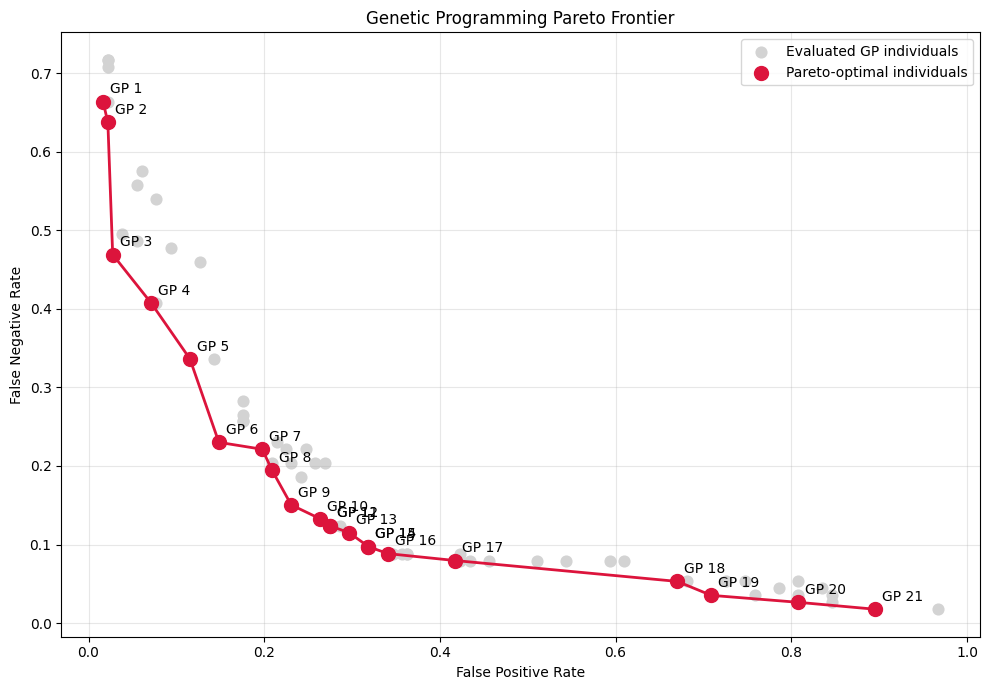


Prediction file preview:


,PassengerId,GP_Individual_1,GP_Individual_2,GP_Individual_3,GP_Individual_4,GP_Individual_5,GP_Individual_6,GP_Individual_7,GP_Individual_8,GP_Individual_9,...,GP_Individual_12,GP_Individual_13,GP_Individual_14,GP_Individual_15,GP_Individual_16,GP_Individual_17,GP_Individual_18,GP_Individual_19,GP_Individual_20,GP_Individual_21
0,892,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,1,0
1,893,0,0,0,1,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1
2,894,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,1
3,895,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,1
4,896,0,0,0,0,1,1,1,1,1,...,1,1,1,1,1,1,1,1,1,1


Prediction columns: 21


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Start with the training Pareto frontier.
training_frontier = non_dominated_sort(population)[0]


# Remove duplicate validation behaviors.
unique_behaviors = {}

for individual in training_frontier:
    validation_predictions = predict_individual(
        individual,
        X_valid_gp
    )

    behavior = tuple(validation_predictions.tolist())

    # Keep the smaller expression when two individuals
    # produce identical predictions.
    if (
        behavior not in unique_behaviors or
        len(individual) < len(unique_behaviors[behavior])
    ):
        unique_behaviors[behavior] = individual


validation_candidates = list(unique_behaviors.values())


# Calculate validation FPR and FNR.
validation_rows = []

for individual in validation_candidates:
    predictions = predict_individual(
        individual,
        X_valid_gp
    )

    tn, fp, fn, tp = confusion_matrix(
        y_valid_gp,
        predictions,
        labels=[0, 1]
    ).ravel()

    validation_rows.append({
        "Individual": individual,
        "Expression": str(individual),
        "TreeSize": len(individual),
        "FPR": fp / (fp + tn),
        "FNR": fn / (fn + tp),
        "Accuracy": (tn + tp) / (tn + fp + fn + tp)
    })


validation_results = pd.DataFrame(validation_rows)


def row_is_dominated(row, table):
    no_worse = (
        (table["FPR"] <= row["FPR"]) &
        (table["FNR"] <= row["FNR"])
    )

    strictly_better = (
        (table["FPR"] < row["FPR"]) |
        (table["FNR"] < row["FNR"])
    )

    return (no_worse & strictly_better).any()


validation_results["Dominated"] = validation_results.apply(
    lambda row: row_is_dominated(row, validation_results),
    axis=1
)


validation_frontier = (
    validation_results[~validation_results["Dominated"]]
    .sort_values(["FPR", "FNR"])
    .reset_index(drop=True)
)


print(
    "Validation Pareto-optimal individuals:",
    len(validation_frontier)
)

display(
    validation_frontier[
        ["TreeSize", "Accuracy", "FPR", "FNR", "Expression"]
    ]
)


# Plot validation results and Pareto frontier.
plt.figure(figsize=(10, 7))

plt.scatter(
    validation_results["FPR"],
    validation_results["FNR"],
    color="lightgray",
    s=60,
    label="Evaluated GP individuals"
)

plt.scatter(
    validation_frontier["FPR"],
    validation_frontier["FNR"],
    color="crimson",
    s=100,
    label="Pareto-optimal individuals",
    zorder=3
)

frontier_line = (
    validation_frontier[["FPR", "FNR"]]
    .drop_duplicates()
    .sort_values("FPR")
)

plt.plot(
    frontier_line["FPR"],
    frontier_line["FNR"],
    color="crimson",
    linewidth=2
)

for index, row in validation_frontier.iterrows():
    plt.annotate(
        f"GP {index + 1}",
        (row["FPR"], row["FNR"]),
        xytext=(5, 6),
        textcoords="offset points"
    )

plt.xlabel("False Positive Rate")
plt.ylabel("False Negative Rate")
plt.title("Genetic Programming Pareto Frontier")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


# Create one prediction column for each Pareto-optimal individual.
submission = pd.DataFrame({
    "PassengerId": test_raw["PassengerId"]
})

summary_rows = []

for index, row in validation_frontier.iterrows():
    individual = row["Individual"]
    column_name = f"GP_Individual_{index + 1}"

    submission[column_name] = predict_individual(
        individual,
        X_kaggle_gp
    )

    summary_rows.append({
        "Column": column_name,
        "ValidationAccuracy": row["Accuracy"],
        "ValidationFPR": row["FPR"],
        "ValidationFNR": row["FNR"],
        "TreeSize": row["TreeSize"],
        "Expression": row["Expression"]
    })


submission.to_csv(
    "gp_pareto_predictions.csv",
    index=False
)

pd.DataFrame(summary_rows).to_csv(
    "gp_pareto_individuals_summary.csv",
    index=False
)


print("\nPrediction file preview:")
display(submission.head())

print(
    "Prediction columns:",
    len(submission.columns) - 1
)


from google.colab import files

files.download("gp_pareto_predictions.csv")
files.download("gp_pareto_individuals_summary.csv")